## Universidad Panamericana Campus Aguascalientes
## Maestría en Inteligencia Artificial y Ciencia de Datos
### Aprendizaje Automático
**Práctica:** Reducción de Dimensionalidad

ID: 0286155

Alumno: Manuel Alejandro Serrano Macias

**Objetivo:** Entrenar y evaluar un modelo de regresión usando Random Forest para predecir la calidad del vino (`quality`). Se compararán tres versiones del modelo: con todas las variables, con las 5 variables más correlacionadas y con las 5 variables de mayor importancia según el primer modelo.

### 1. Importar librerías y cargar el dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# 1. Cargar dataset
df = pd.read_csv('wine.csv')
df.shape

(1599, 12)

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### 2. Dividir los datos en X (variables de entrada), y (variable de salida: quality)

In [4]:
# 2. Dividir los datos en X (variables de entrada) y Y (variable de salida: quality)
X = df.drop(columns=['quality'])
y = df['quality']

In [5]:
print('Variables de entrada(X):')
print(X.columns.tolist())

Variables de entrada(X):
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [6]:
print('Variable de salida (y):')
print(y.describe())

Variable de salida (y):
count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64


In [7]:
# División 70% entrenamiento / 30% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('Tamaño entrenamiento:', X_train.shape)
print('Tamaño prueba:       ', X_test.shape)

Tamaño entrenamiento: (1119, 11)
Tamaño prueba:        (480, 11)


### 3. Random Forest con todas las variables

In [8]:
# Entrenamos el modelo con todas las variables
rf_full = RandomForestRegressor(n_estimators=100, random_state=42)
rf_full.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### 4. Calcular los valores MAE y R^2

In [9]:
# Predicciones sobre el conjunto de prueba
y_pred_full = rf_full.predict(X_test)

# Métricas
mae_full = mean_absolute_error(y_test, y_pred_full)
r2_full  = r2_score(y_test, y_pred_full)

print('Random Forest: Todas las variables')
print(f'MAE : {mae_full:.4f}')
print(f'R²  : {r2_full:.4f}')

Random Forest: Todas las variables
MAE : 0.4441
R²  : 0.4507


### 5. Gráfica de dispersión

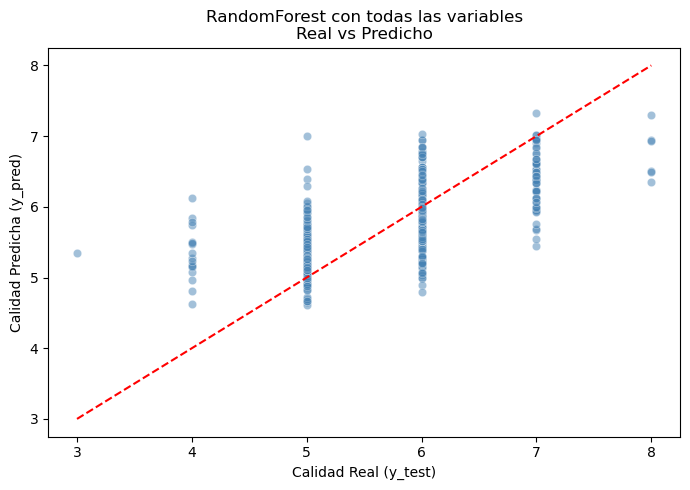

In [10]:
# Gráfica de dispersión: valores reales vs predichos
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_full, alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel('Calidad Real (y_test)')
plt.ylabel('Calidad Predicha (y_pred)')
plt.title('RandomForest con todas las variables\nReal vs Predicho')
plt.tight_layout()
plt.show()

### 6. Matriz de correlación

Identificar las 5 variables más correlacionadas con `quality`

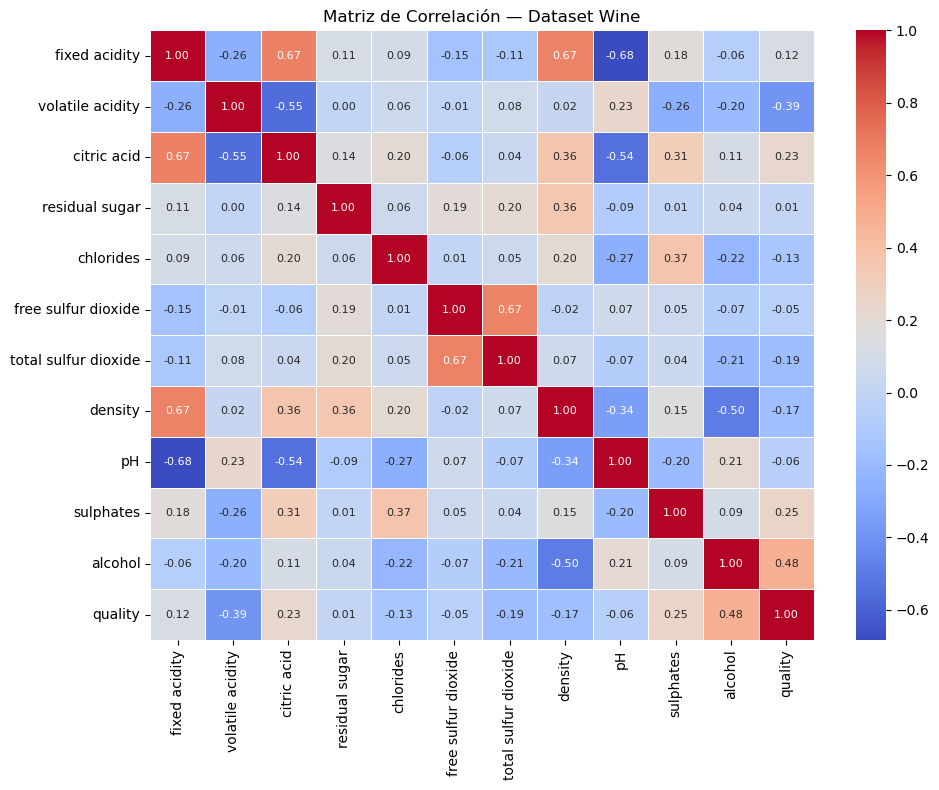

In [11]:
# Calculamos la matriz de correlación completa
corr_matrix = df.corr()

# Visualizamos el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de Correlación — Dataset Wine')
plt.tight_layout()
plt.show()

In [12]:
# Extraemos la correlación de cada variable con 'quality' (en valor absoluto)
corr_quality = corr_matrix['quality'].drop('quality').abs().sort_values(ascending=False)

print('Correlación (valor absoluto) con quality:')
print(corr_quality)

# Seleccionamos las 5 variables con mayor correlación
top5_corr = corr_quality.head(5).index.tolist()
print('\nTop 5 variables más correlacionadas:', top5_corr)

Correlación (valor absoluto) con quality:
alcohol                 0.476166
volatile acidity        0.390558
sulphates               0.251397
citric acid             0.226373
total sulfur dioxide    0.185100
density                 0.174919
chlorides               0.128907
fixed acidity           0.124052
pH                      0.057731
free sulfur dioxide     0.050656
residual sugar          0.013732
Name: quality, dtype: float64

Top 5 variables más correlacionadas: ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'total sulfur dioxide']


Usamos el valor absoluto de la correlación porque tanto una correlación muy positiva como muy negativa indican una relación fuerte con la variable de salida.

### 7. Entrenar nuevamente Random Forest con las 5 variables más correlacionadas, calcular MAE y R^2, gráficar dispersión

In [13]:
# Filtramos sólo las 5 variables más correlacionadas
X_train_corr = X_train[top5_corr]
X_test_corr  = X_test[top5_corr]

# Entrenamos el modelo
rf_corr = RandomForestRegressor(n_estimators=100, random_state=42)
rf_corr.fit(X_train_corr, y_train)

RandomForestRegressor(random_state=42)

In [14]:
# Predicciones y métricas
y_pred_corr = rf_corr.predict(X_test_corr)
mae_corr = mean_absolute_error(y_test, y_pred_corr)
r2_corr  = r2_score(y_test, y_pred_corr)

print('Random Forest: Top 5 correlación')
print(f'Variables: {top5_corr}')
print(f'MAE : {mae_corr:.4f}')
print(f'R²  : {r2_corr:.4f}')

Random Forest: Top 5 correlación
Variables: ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'total sulfur dioxide']
MAE : 0.4476
R²  : 0.4280


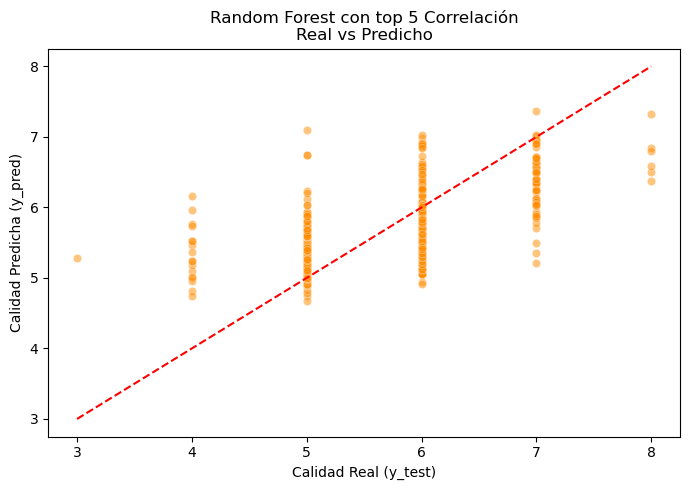

In [15]:
# Gráfica de dispersión
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_corr, alpha=0.5, color='darkorange', edgecolors='white', linewidths=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel('Calidad Real (y_test)')
plt.ylabel('Calidad Predicha (y_pred)')
plt.title('Random Forest con top 5 Correlación\nReal vs Predicho')
plt.tight_layout()
plt.show()

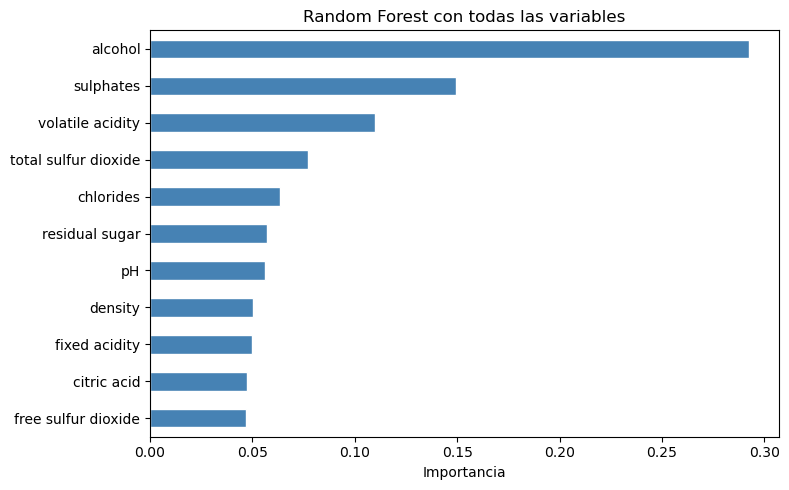


Top 5 variables por Feature Importance:
alcohol                 0.292471
sulphates               0.149310
volatile acidity        0.109989
total sulfur dioxide    0.077201
chlorides               0.063492
dtype: float64

Variables seleccionadas: ['alcohol', 'sulphates', 'volatile acidity', 'total sulfur dioxide', 'chlorides']


In [16]:
# Extraemos la importancia de cada variable del modelo original (Random Forest todas las variables)
importancias = pd.Series(rf_full.feature_importances_, index=X.columns)
importancias_sorted = importancias.sort_values(ascending=True)

# Gráfica de barras horizontales
plt.figure(figsize=(8, 5))
importancias_sorted.plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Importancia')
plt.title('Random Forest con todas las variables')
plt.tight_layout()
plt.show()

# Top 5 variables más importantes
top5_fi = importancias.sort_values(ascending=False).head(5).index.tolist()
print('\nTop 5 variables por Feature Importance:')
print(importancias.sort_values(ascending=False).head(5))
print('\nVariables seleccionadas:', top5_fi)

### 8. Random Forest con las 5 variables de mayor Feature Importance

In [17]:
# Filtramos sólo las 5 variables de mayor importancia
X_train_fi = X_train[top5_fi]
X_test_fi  = X_test[top5_fi]

# Entrenamos el modelo
rf_fi = RandomForestRegressor(n_estimators=100, random_state=42)
rf_fi.fit(X_train_fi, y_train)

RandomForestRegressor(random_state=42)

In [18]:
# Predicciones y métricas
y_pred_fi = rf_fi.predict(X_test_fi)
mae_fi = mean_absolute_error(y_test, y_pred_fi)
r2_fi  = r2_score(y_test, y_pred_fi)

print('Random Forest: Top 5 Feature Importance')
print(f'Variables: {top5_fi}')
print(f'MAE : {mae_fi:.4f}')
print(f'R²  : {r2_fi:.4f}')

Random Forest: Top 5 Feature Importance
Variables: ['alcohol', 'sulphates', 'volatile acidity', 'total sulfur dioxide', 'chlorides']
MAE : 0.4411
R²  : 0.4403


ERROR! Session/line number was not unique in database. History logging moved to new session 72


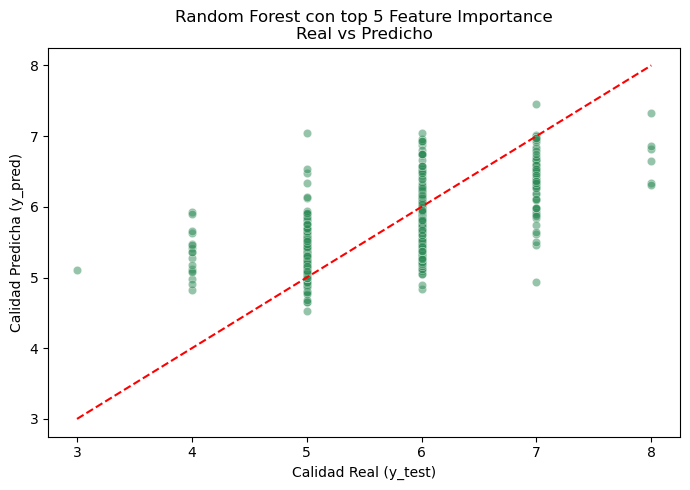

In [19]:
# Gráfica de dispersión
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_fi, alpha=0.5, color='seagreen', edgecolors='white', linewidths=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel('Calidad Real (y_test)')
plt.ylabel('Calidad Predicha (y_pred)')
plt.title('Random Forest con top 5 Feature Importance\nReal vs Predicho')
plt.tight_layout()
plt.show()

### 9. Comparación de los tres modelos

In [20]:
# Tabla comparativa
resultados = pd.DataFrame({
    'Modelo': [
        'Modelo 1 — Regression Forest con todas las variables (11)',
        'Modelo 2 — Regression Forest con top 5 Correlación',
        'Modelo 3 — Regression Forest con top 5 Feature Importance'
    ],
    'MAE':  [mae_full, mae_corr, mae_fi],
    'R²':   [r2_full,  r2_corr,  r2_fi]
})
print(resultados.to_string(index=False))

                                                   Modelo      MAE       R²
Modelo 1 — Regression Forest con todas las variables (11) 0.444146 0.450711
       Modelo 2 — Regression Forest con top 5 Correlación 0.447583 0.428002
Modelo 3 — Regression Forest con top 5 Feature Importance 0.441125 0.440305


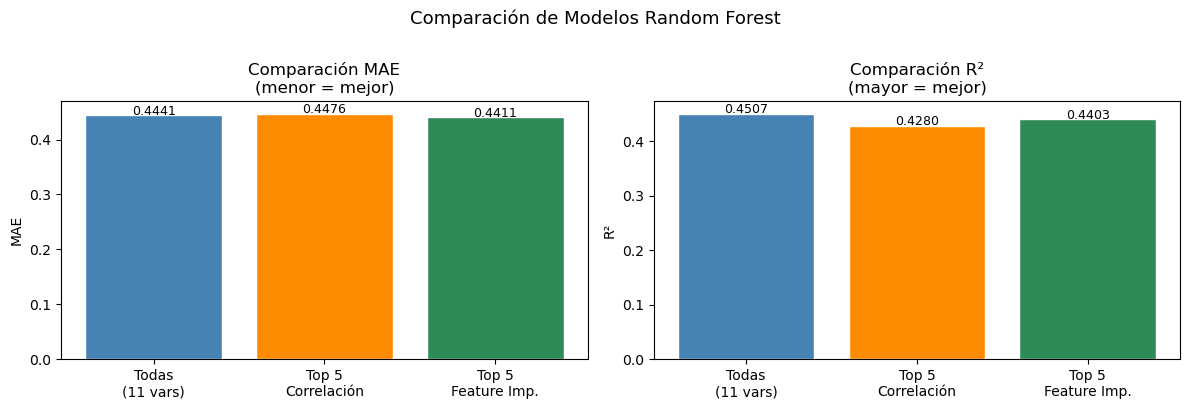

In [21]:
# Gráfica comparativa de MAE y R²
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

modelos  = ['Todas\n(11 vars)', 'Top 5\nCorrelación', 'Top 5\nFeature Imp.']
colores  = ['steelblue', 'darkorange', 'seagreen']

# MAE (menor es mejor)
axes[0].bar(modelos, [mae_full, mae_corr, mae_fi], color=colores, edgecolor='white')
axes[0].set_title('Comparación MAE\n(menor = mejor)')
axes[0].set_ylabel('MAE')
for i, v in enumerate([mae_full, mae_corr, mae_fi]):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

# R² (mayor es mejor)
axes[1].bar(modelos, [r2_full, r2_corr, r2_fi], color=colores, edgecolor='white')
axes[1].set_title('Comparación R²\n(mayor = mejor)')
axes[1].set_ylabel('R²')
for i, v in enumerate([r2_full, r2_corr, r2_fi]):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Comparación de Modelos Random Forest', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Conclusiones

Al comparar los tres modelos de Random Forest entrenados con el dataset de vino, se pueden observar diferencias interesantes.

El Modelo 1, entrenado con las 11 variables, obtuvo el mejor desempeño general en términos de MAE y R², lo cual es esperable porque cuenta con más información disponible para aprender. Sin embargo, la diferencia con los otros modelos no es drástica, lo que sugiere que no todas las variables aportan información igualmente relevante.

El Modelo 2, entrenado con las 5 variables de mayor correlación con `quality`, logró un desempeño competitivo. Esto confirma que variables como `alcohol` y `volatile acidity` tienen una relación directa con la calidad del vino y son suficientes para capturar buena parte de la variabilidad.

El Modelo 3, basado en las 5 variables de mayor Feature Importance del modelo original, también tuvo un rendimiento cercano al modelo completo. Esto demuestra que el Random Forest es capaz de identificar internamente qué variables son más informativas, y que usar solo esas variables puede reducir la complejidad del modelo sin sacrificar demasiado desempeño.

En general, la selección de variables, ya sea por correlación o por importancia, es una técnica útil para simplificar modelos, reducir tiempos de entrenamiento y evitar ruido innecesario. En este caso, la Feature Importance resultó ser un criterio ligeramente más robusto que la correlación, ya que considera relaciones no lineales entre variables.